# Predict which employees are likely to leave the business?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
pd.set_option("display.max_columns", None)

### Load Data

In [3]:
data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### Assess Duplicates & Data Types

In [4]:
data[data.duplicated()]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [5]:
data.EmployeeNumber.nunique()

1470

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### Assess Missing Data 

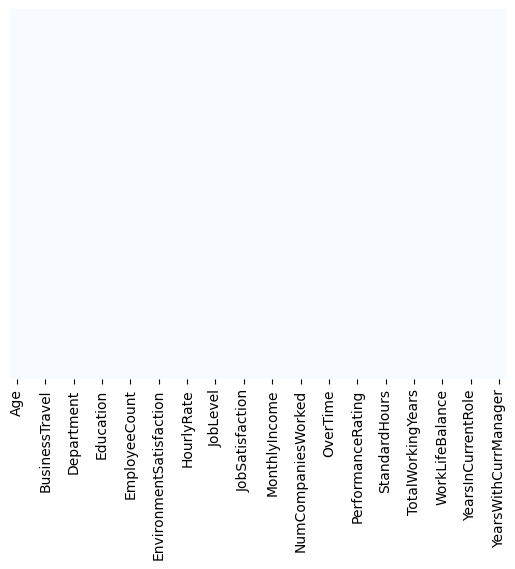

In [7]:
sns.heatmap(data.isnull(),yticklabels= False, cbar =False, cmap= 'Blues');

#Disabled ytick labels & torned the color bar off because we have a binary output.

__Commments Datatype & Duplicates__
* Data doesn't have duplicates and each row represents 1 employee
* Data types numeric & categorical are correct
* Data has no missing values

### Assess If Categorical Features, Categories Are Recorded Uniformly

In [8]:
#Subsetting categorical variables into a df
category_df = data.select_dtypes(include={"string","object"})

category_df.head()

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No


In [9]:
category_df.Attrition.value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [10]:
category_df.Over18.value_counts()

Over18
Y    1470
Name: count, dtype: int64

In [11]:
category_df.OverTime.value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

In [12]:
category_df.BusinessTravel.value_counts()

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

In [13]:
category_df.Department.value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [14]:
category_df.EducationField.value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

In [15]:
category_df.Gender.value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

In [16]:
category_df.JobRole.value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

In [17]:
category_df.MaritalStatus.value_counts()

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

__Categoric Variables Comments__

* The categories in each variable are named consistently. No adjustments are required
* The Over18 variable has only 1 value= Yes. I will drop this feature because we expect it to remain the same and it's can't explain any variation in attrition.

__Drop Feature Over18__

In [18]:
data.drop(columns= ["Over18"], inplace =True)

### Convert Attrition & OverTime into binary variables

In [19]:
mapping = {"Yes": 1, "No": 0}

In [20]:
data["Attrition"]=data["Attrition"].map(mapping)

data["OverTime"] = data["OverTime"].map(mapping)

### Assess Numeric Features 

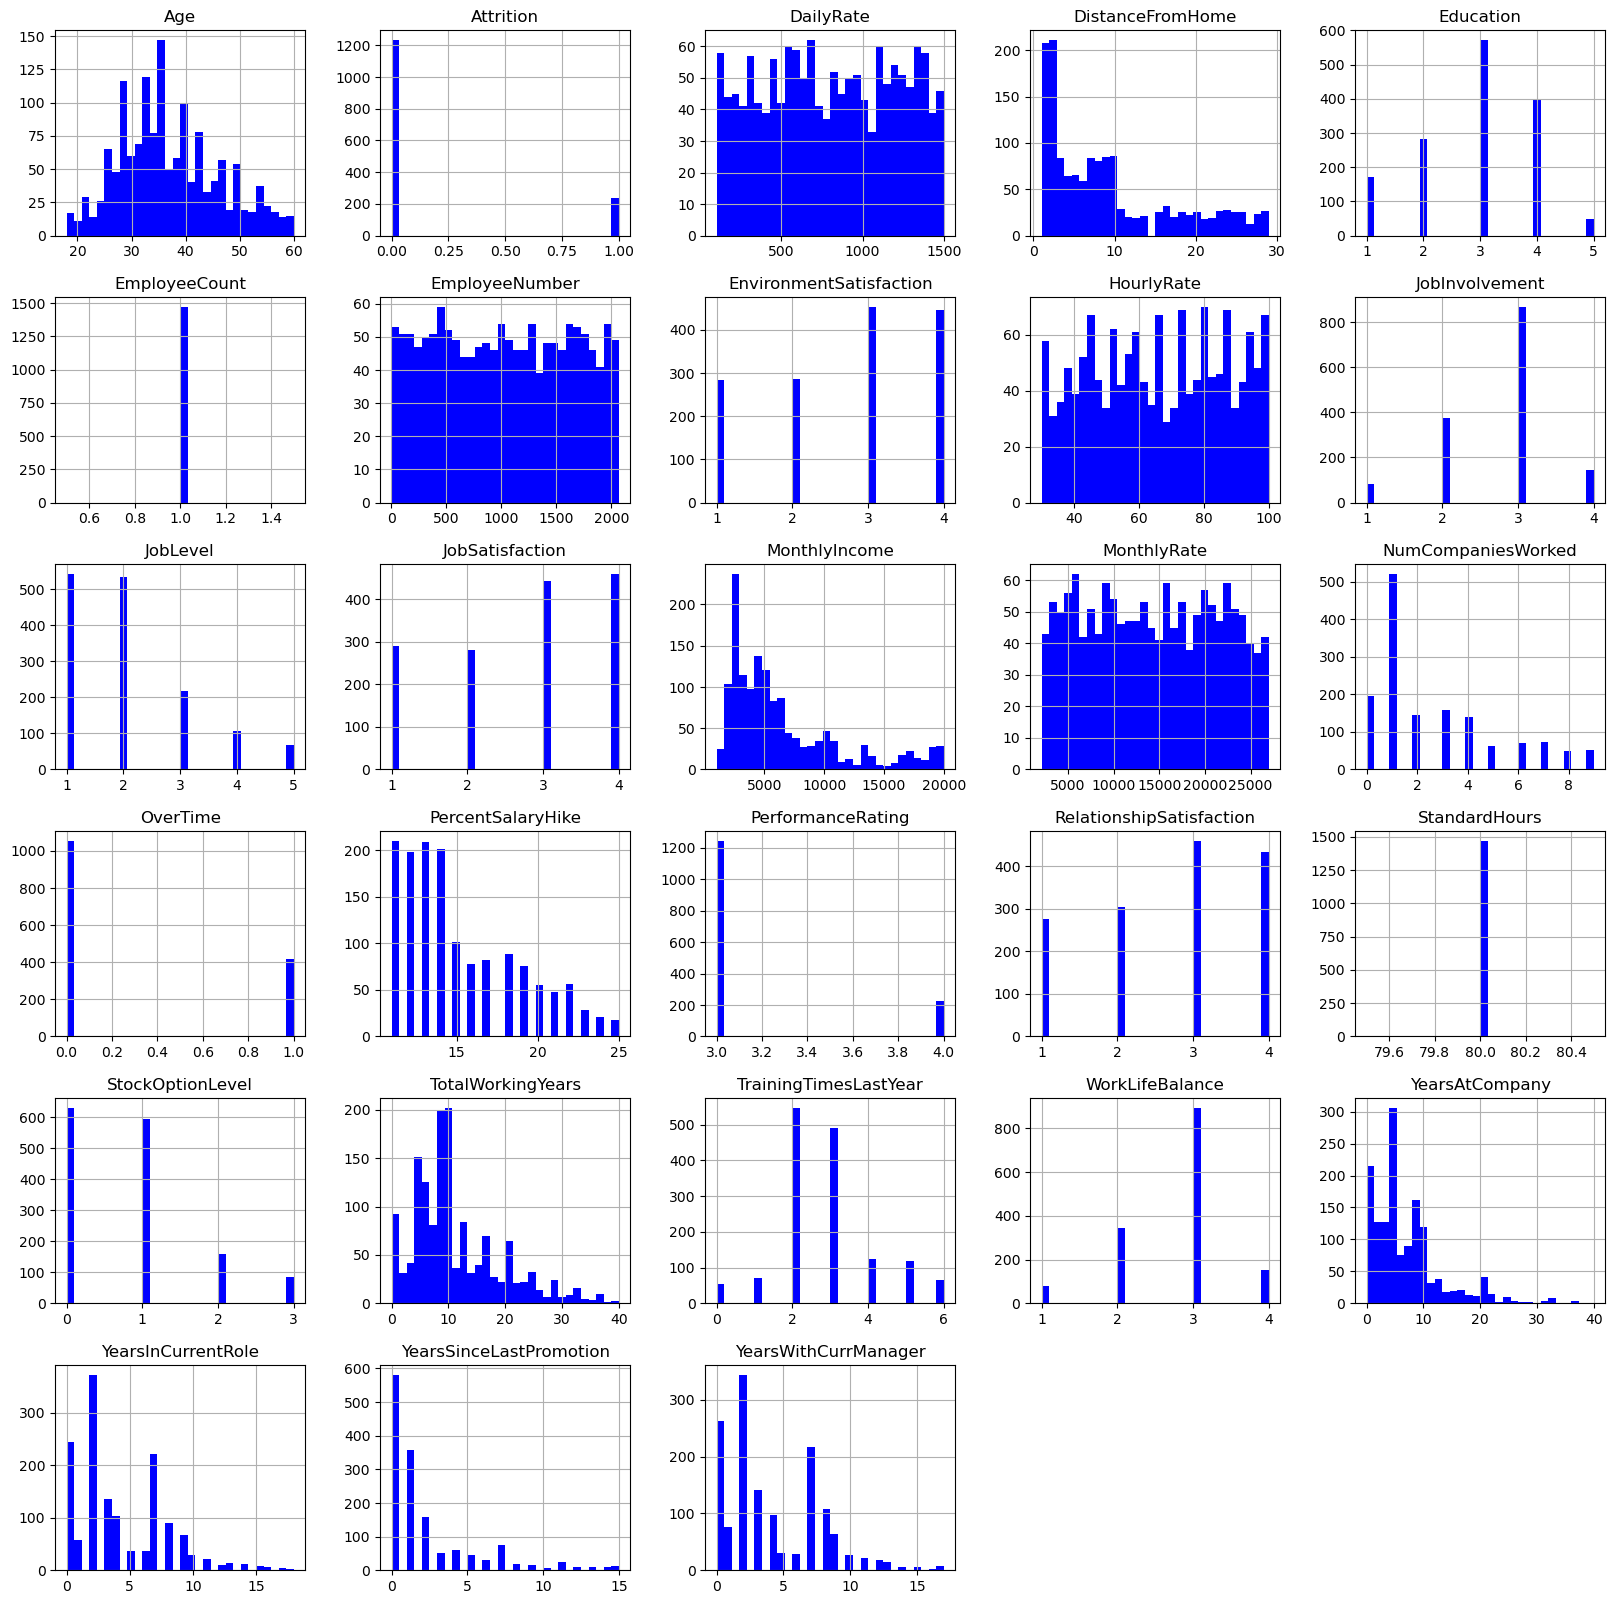

In [21]:
data.hist(bins = 30, figsize = (20,20), color = 'Blue');

__Numeric Features Data Summary__

In [22]:
data.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,0.282993,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,0.450606,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,0.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,0.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,1.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,1.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


__Numeric Feature Comments__
* Features StandardHours & EmployeeCount have 1 output similar to Over18, they won't explain variations in attrition. I will drop them.
* Numeric features have different distributions.
* Numeric feature summary look reasonable

__Drop StandardHours & EmployeeCount__

In [23]:
data.drop(columns = ['StandardHours', 'EmployeeCount'], inplace = True )

In [24]:
# drop columns standard hours, over18,employeeCount
employee_data = data.copy()

In [25]:
employee_data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2


__Overall Data(categorical + Numeric) Comments__
* There are 3 numeric features(Age,YearsAtCompany & MonthlyIncome) that don't give me sufficient data to assess how they impact attrition. I will study them and create bands for further analysis.

### Assess if categorical variables are good predictors of Attrition

In [26]:
employee_data.select_dtypes(include ={"object","str"}).columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus'],
      dtype='str')

### Check Association between Attrition & Features
__Hypothesis Testing__

* H0: Categorical feature is independent of Attrition(There is association)
* H1: Categorical feature is dependent on Attritrion(Association is absent)

In [27]:
#Categorical variables to test
categorical_vars = ['BusinessTravel', 'Department', 'EducationField','Gender', 'JobRole','MaritalStatus']

In [28]:
results = []

for var in categorical_vars:
    contingency_table = pd.crosstab(employee_data['Attrition'], employee_data[var])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    results.append({
        'Variable': var,
        'Chi2': chi2,
        'p-value': p,
        'Degrees of Freedom': dof,
        'Outcome': 'Reject H0, variable is significant' if p < 0.05 else 'Fail To Reject H0'
    })

# Convert results to DataFrame for easy viewing
results_df = pd.DataFrame(results)
print(results_df)

         Variable       Chi2       p-value  Degrees of Freedom  \
0  BusinessTravel  24.182414  5.608614e-06                   2   
1      Department  10.796007  4.525607e-03                   2   
2  EducationField  16.024674  6.773980e-03                   5   
3          Gender   1.116967  2.905724e-01                   1   
4         JobRole  86.190254  2.752482e-15                   8   
5   MaritalStatus  46.163677  9.455511e-11                   2   

                              Outcome  
0  Reject H0, variable is significant  
1  Reject H0, variable is significant  
2  Reject H0, variable is significant  
3                   Fail To Reject H0  
4  Reject H0, variable is significant  
5  Reject H0, variable is significant  


__Assess the strength of the associations__

In [29]:
# Cramer's V calculation


def cramers_v(data, feature, target='Attrition'):
    """
    Calculate Cramer's V statistic for categorical association.
    """

    contingency_table = pd.crosstab(data[feature], data[target])

    chi2 = chi2_contingency(contingency_table)[0]

    n = contingency_table.sum().sum()

    min_dim = min(contingency_table.shape) - 1

    return np.sqrt(chi2 / (n * min_dim))



results = []

for var in categorical_vars:
    v = cramers_v(employee_data, var)

    results.append({
        'Variable': var,
        'Cramers_V': round(v, 3)
    })

cramer_results = pd.DataFrame(results)

cramer_results = cramer_results.sort_values(
    by='Cramers_V',
    ascending=False
)

print(cramer_results)


         Variable  Cramers_V
4         JobRole      0.242
5   MaritalStatus      0.177
0  BusinessTravel      0.128
2  EducationField      0.104
1      Department      0.086
3          Gender      0.028


__Categorical Variables Checks__
* Gender showed a negligible association (Cramér's V = 0.028) and no statical significance, I will drop it.
* Department exhibited a statistically significant but practically weak relationship (Cramér's V = 0.086), suggesting limited explanatory value but I will keep for further analysis.

In [30]:
employee_data.drop(columns = ['Gender'], inplace = True )

### Assess multicollinearity for categorical variables

In [31]:
categorical_vars = ['BusinessTravel', 'Department', 'EducationField', 'JobRole','MaritalStatus']

In [32]:

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()

    phi2 = chi2 / n
    r, k = contingency.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))


In [33]:

results = []

for i in range(len(categorical_vars)):
    for j in range(i+1, len(categorical_vars)):
        v = cramers_v(
            employee_data[categorical_vars[i]],
            employee_data[categorical_vars[j]]
        )

        results.append({
            'Variable_1': categorical_vars[i],
            'Variable_2': categorical_vars[j],
            'Cramers_V': round(v, 3)
        })

pairwise_df = pd.DataFrame(results)


In [34]:
pairwise_df

,Variable_1,Variable_2,Cramers_V
0,BusinessTravel,Department,0.008
1,BusinessTravel,EducationField,0.042
2,BusinessTravel,JobRole,0.064
3,BusinessTravel,MaritalStatus,0.051
4,Department,EducationField,0.590
5,Department,JobRole,0.939
6,Department,MaritalStatus,0.048
7,EducationField,JobRole,0.343
8,EducationField,MaritalStatus,0.057
9,JobRole,MaritalStatus,0.096


* Department and jobrole are telling us the same story (vif= 0.939). I will drop department because the department has weaker association =0.086 with attrition compared to that of jobrole = 0.242
* Department and EducationField  are making sense because different educationfields map to their respective departments.

In [35]:
employee_data.drop(columns = ["Department"], inplace= True)

### Assess If Numeric Variables are suitable predictors of Attrition

In [36]:
numeric_features =employee_data.select_dtypes(exclude ={"object","string"})

In [37]:
numeric_features.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1102,1,2,1,2,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,0,279,8,1,2,3,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,1,1373,2,2,4,4,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,0,1392,3,4,5,4,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,0,591,2,1,7,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2


In [38]:
numeric_vars = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
                'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']

### Run t-test because Attrition is a binary feature.

__Hypothesis Testing__
* H0: Mean __Feature__ who left = Mean __Feature__ who stayed (Feature Not useful in Attrition determination)
* H1: Mean __Feature__ differ between attrition groups(Feature important in determining attrition)

In [39]:

results = []

for var in numeric_vars:

    stayed = employee_data.loc[
        employee_data['Attrition'] == 0, var
    ]

    left = employee_data.loc[
        employee_data['Attrition'] == 1, var
    ]

    t_stat, p_value = ttest_ind(
        stayed,
        left,
        equal_var=False
    )

    results.append({
        'Variable': var,
        'T Statistic': round(t_stat, 3),
        'p-value': round(p_value, 5),
        'Outcome': 'Reject H0, feature important' if p_value < 0.05 else 'Fail To Reject H0: Feature not useful'
    })

results_df = pd.DataFrame(results).sort_values('p-value')

print(results_df)


                    Variable  T Statistic  p-value  \
0                        Age        5.828  0.00000   
7                   JobLevel        7.386  0.00000   
6             JobInvolvement        4.660  0.00000   
9              MonthlyIncome        7.483  0.00000   
12                  OverTime       -8.705  0.00000   
21        YearsInCurrentRole        6.847  0.00000   
17         TotalWorkingYears        7.019  0.00000   
16          StockOptionLevel        5.244  0.00000   
20            YearsAtCompany        5.283  0.00000   
23      YearsWithCurrManager        6.633  0.00000   
8            JobSatisfaction        3.926  0.00011   
4    EnvironmentSatisfaction        3.751  0.00021   
2           DistanceFromHome       -2.888  0.00414   
18     TrainingTimesLastYear        2.331  0.02036   
1                  DailyRate        2.179  0.03004   
19           WorkLifeBalance        2.174  0.03047   
15  RelationshipSatisfaction        1.702  0.08973   
11        NumCompaniesWorked

In [40]:
numeric_investigate = results_df[results_df.Outcome== 'Fail To Reject H0: Feature not useful']
numeric_investigate

,Variable,T Statistic,p-value,Outcome
15,RelationshipSatisfaction,1.702,0.08973,Fail To Reject H0: Feature not useful
11,NumCompaniesWorked,-1.575,0.11633,Fail To Reject H0: Feature not useful
22,YearsSinceLastPromotion,1.288,0.19865,Fail To Reject H0: Feature not useful
3,Education,1.218,0.22417,Fail To Reject H0: Feature not useful
10,MonthlyRate,-0.576,0.56534,Fail To Reject H0: Feature not useful
13,PercentSalaryHike,0.504,0.61443,Fail To Reject H0: Feature not useful
5,HourlyRate,0.265,0.79135,Fail To Reject H0: Feature not useful
14,PerformanceRating,-0.110,0.91248,Fail To Reject H0: Feature not useful


In [41]:
attrition_corr= numeric_features.corr(method = 'spearman')['Attrition'].sort_values(key=abs, ascending=False)

attrition_corr

Attrition                   1.000000
OverTime                    0.246118
TotalWorkingYears          -0.199002
MonthlyIncome              -0.198305
YearsAtCompany             -0.190419
JobLevel                   -0.190370
YearsInCurrentRole         -0.180623
YearsWithCurrManager       -0.175355
StockOptionLevel           -0.172296
Age                        -0.171214
JobInvolvement             -0.119496
JobSatisfaction            -0.102948
EnvironmentSatisfaction    -0.096486
DistanceFromHome            0.079248
DailyRate                  -0.056970
YearsSinceLastPromotion    -0.053273
WorkLifeBalance            -0.051951
TrainingTimesLastYear      -0.051757
RelationshipSatisfaction   -0.042664
NumCompaniesWorked          0.030505
Education                  -0.030346
PercentSalaryHike          -0.023612
MonthlyRate                 0.015258
EmployeeNumber             -0.010369
HourlyRate                 -0.006692
PerformanceRating           0.002889
Name: Attrition, dtype: float64

In [42]:
#Select |r|<0.1
weak_corr = attrition_corr[
    attrition_corr.abs() < 0.1
].sort_values(key=abs)

print(weak_corr)

PerformanceRating           0.002889
HourlyRate                 -0.006692
EmployeeNumber             -0.010369
MonthlyRate                 0.015258
PercentSalaryHike          -0.023612
Education                  -0.030346
NumCompaniesWorked          0.030505
RelationshipSatisfaction   -0.042664
TrainingTimesLastYear      -0.051757
WorkLifeBalance            -0.051951
YearsSinceLastPromotion    -0.053273
DailyRate                  -0.056970
DistanceFromHome            0.079248
EnvironmentSatisfaction    -0.096486
Name: Attrition, dtype: float64


### Variables that failed the t-test and have |correlation with attrition|<0.1 I ran through LOGISTIC REGRESSION TO TEST IMPORTANCE OF VARIABLES

In [43]:

numeric_investigate = ['RelationshipSatisfaction','NumCompaniesWorked','YearsSinceLastPromotion','Education','MonthlyRate','PercentSalaryHike','HourlyRate','PerformanceRating']

X = employee_data[numeric_investigate]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=numeric_investigate
)

X_scaled = sm.add_constant(X_scaled)

y = employee_data['Attrition']

model = sm.Logit(y, X_scaled).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.437984
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1461
Method:                           MLE   Df Model:                            8
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                0.008402
Time:                        16:03:32   Log-Likelihood:                -643.84
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                    0.2068
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.6678      0.072    -23.137      0.000      -1.809

__Numerical Features To Be Dropped__
* All variables not significant in the t-test, |r|<0.1 and P_Value<0.05 in logistic regression will be dropped.

In [44]:
employee_data.drop(columns= numeric_investigate, inplace =True)

In [45]:
numeric_features1 =employee_data.select_dtypes(exclude ={"object","string"})

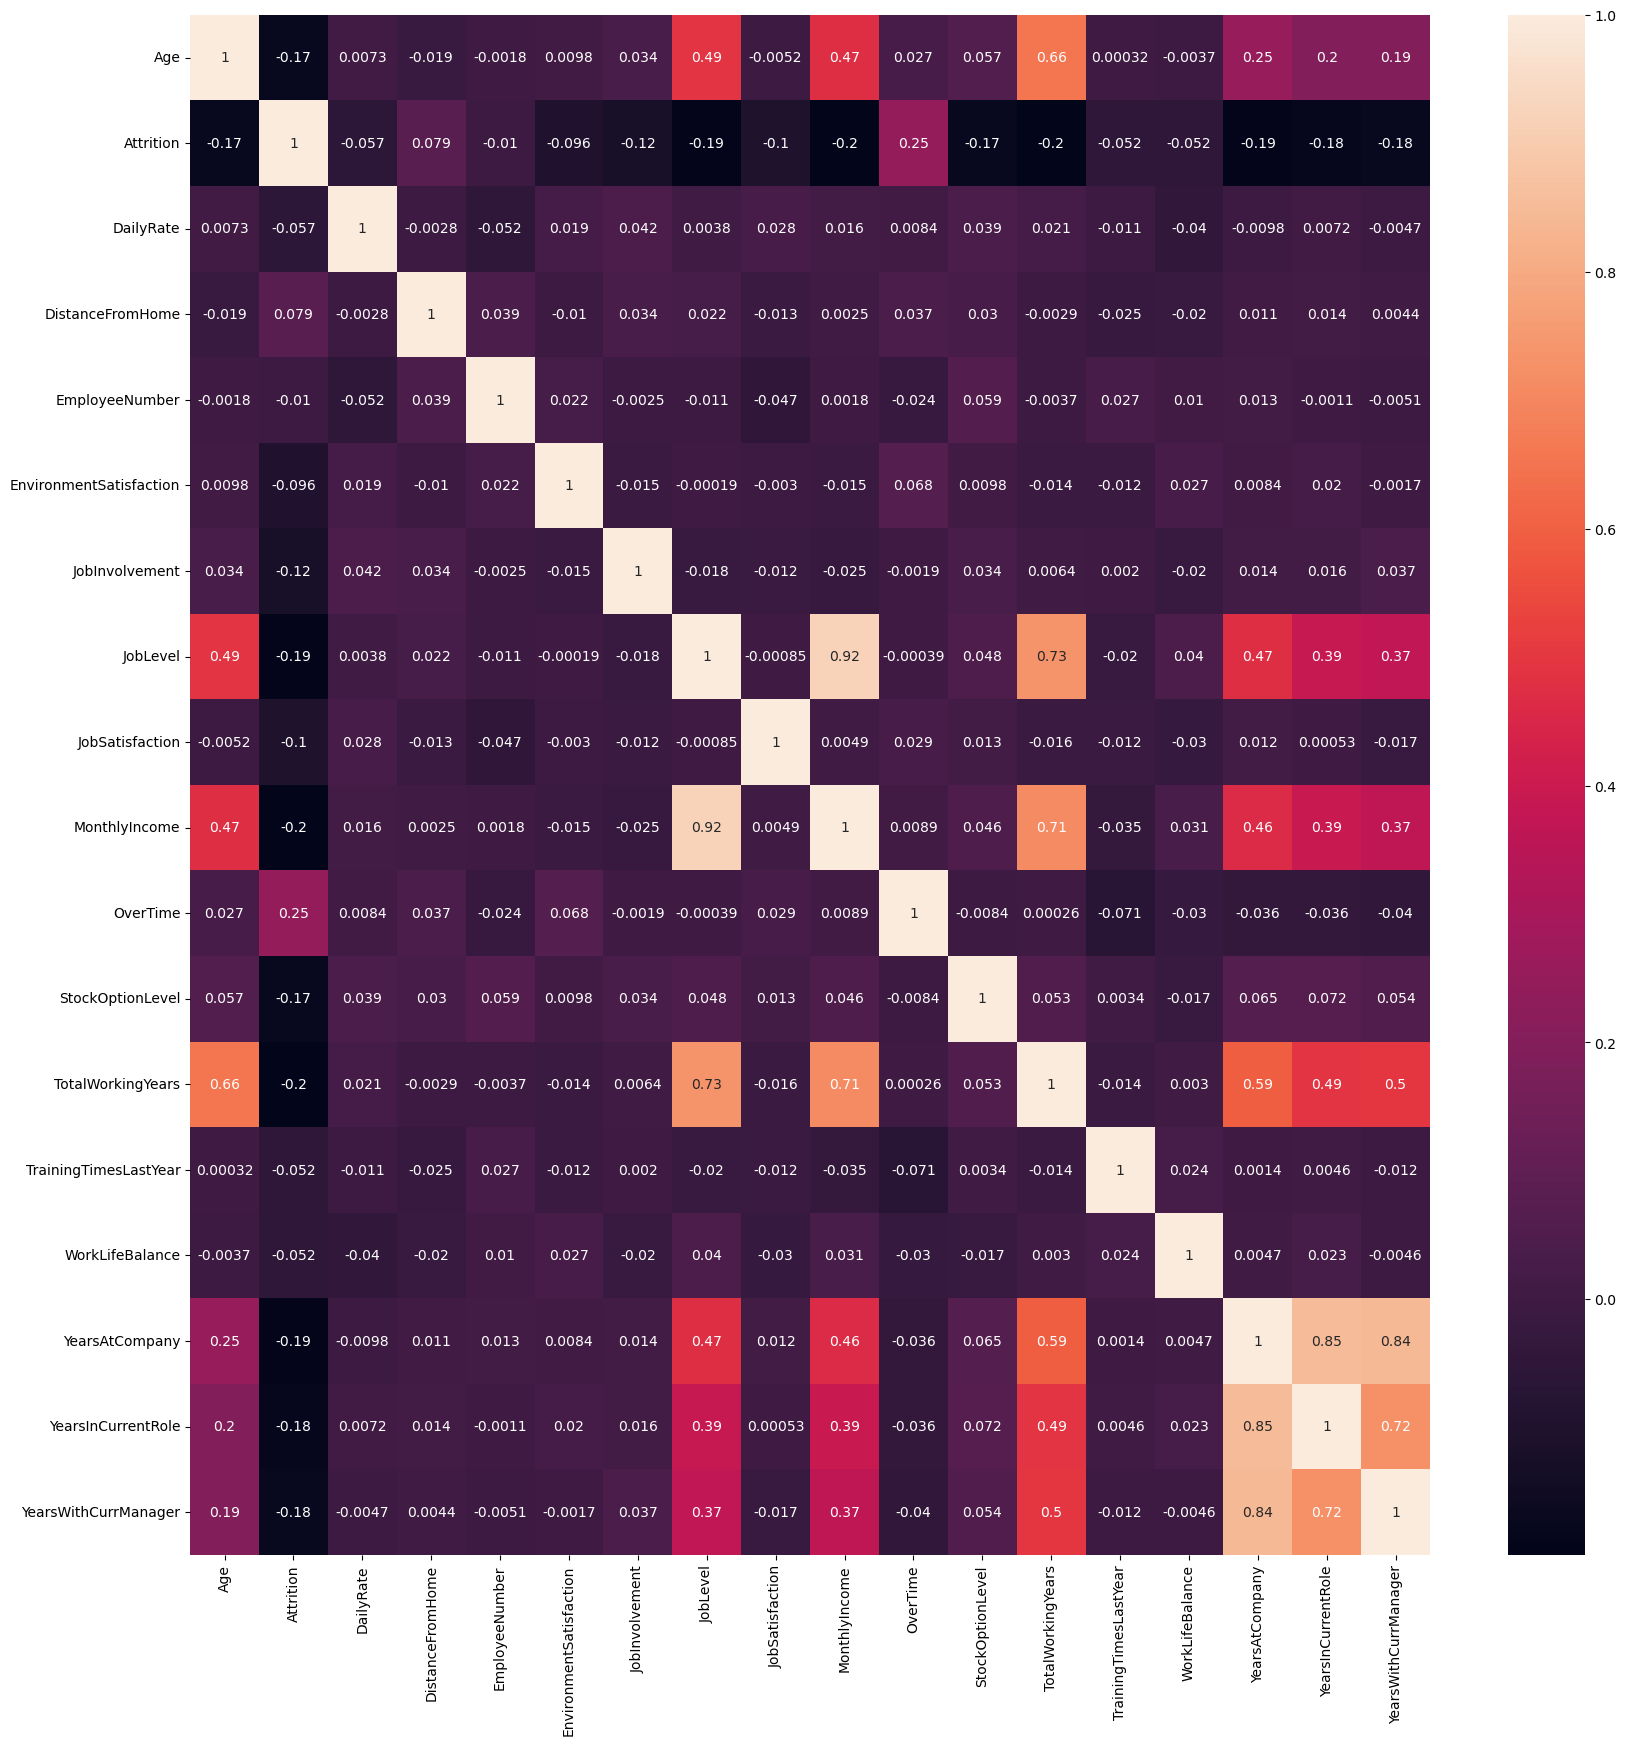

In [46]:
correlations = numeric_features1.corr(method = 'spearman')
f, ax = plt.subplots(figsize = (20, 20))
sns.heatmap(correlations, annot = True);

__The seniority cluster__ — JobLevel <> MonthlyIncome (0.92), YearsAtCompany <> YearsInCurrentRole (0.854), YearsAtCompany <> YearsWithCurrManager (0.843), JobLevel <> TotalWorkingYears (0.735), YearsInCurrentRole <> YearsWithCurrManager (0.725), MonthlyIncome <> TotalWorkingYears (0.71), Age <> TotalWorkingYears (0.657), TotalWorkingYears <> YearsAtCompany (0.594) -are the group of variables that also happen to top the "vs. Attrition" ranking (TotalWorkingYears -0.199, MonthlyIncome -0.198, YearsAtCompany -0.190, JobLevel -0.190). This signals the seniority career growth signal, showing up 7-8 times, each time looking like an independent occurence when it isn't.

__Age,JobLevel, MonthlyIncome, YearsAtCompany, TotalWorkingYears, YearsInCurrentRole,Age, YearsWithCurrManager,YearsInCurrentRole__ These are telling the same story. Select about 2 features to represent the cluster(monthlyincome(salary bands)/ YearsAtCompany(Tenure))


__Add comments, the feat*feat corr used to bring about clusters__

__Use Vif to determine which vars are highly multicorrelated to remove redundant features__

In [47]:
numeric_features1.columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'OverTime', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager'],
      dtype='str')

In [48]:
#Exclude 'Attrition','EmployeeNumber'

X= employee_data[['Age', 'DailyRate', 'DistanceFromHome',
       'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'OverTime', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']]
X = sm.add_constant(X)

vif_df = pd.DataFrame()

vif_df["Variable"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_df)



                   Variable        VIF
0                     const  76.889073
1                       Age   1.964270
2                 DailyRate   1.013863
3          DistanceFromHome   1.010684
4   EnvironmentSatisfaction   1.008784
5            JobInvolvement   1.010720
6                  JobLevel  11.158240
7           JobSatisfaction   1.005761
8             MonthlyIncome  10.767307
9                  OverTime   1.017281
10         StockOptionLevel   1.010600
11        TotalWorkingYears   4.535583
12    TrainingTimesLastYear   1.012008
13          WorkLifeBalance   1.014363
14           YearsAtCompany   4.031166
15       YearsInCurrentRole   2.652816
16     YearsWithCurrManager   2.770320


__Severe multicollinearity (VIF > 10):__ JobLevel (11.21) and MonthlyIncome (10.80) - this is a stronger warning than the pairwise correlation (0.92) alone suggested, because VIF captures how predictable a variable is from all the others combined.__Here I will drop JobLevel__

__Moderate concern (VIF 4-5):__ TotalWorkingYears (4.77), YearsAtCompany (4.59) - these are very close to cut-off (VIF > 5).

All the other features are fine because they have a VIF range(1.0-2.8), meaning they're not predictable from the other variables, so there is no redundancy concern there.

In [49]:
employee_data.drop(columns= ['JobLevel'],inplace=True)

### Assess If there is a relationship between categoric and numeric features

In [50]:
employee_data.head() #.columns

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,EducationField,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,1,Life Sciences,1,2,3,Sales Executive,4,Single,5993,1,0,8,0,1,6,4,5
1,49,0,Travel_Frequently,279,8,Life Sciences,2,3,2,Research Scientist,2,Married,5130,0,1,10,3,3,10,7,7
2,37,1,Travel_Rarely,1373,2,Other,4,4,2,Laboratory Technician,3,Single,2090,1,0,7,3,3,0,0,0
3,33,0,Travel_Frequently,1392,3,Life Sciences,5,4,3,Research Scientist,3,Married,2909,1,0,8,3,3,8,7,0
4,27,0,Travel_Rarely,591,2,Medical,7,1,3,Laboratory Technician,2,Married,3468,0,1,6,3,3,2,2,2


In [51]:
shortlist_numeric = ['Age', 'DailyRate', 'DistanceFromHome',
       'EnvironmentSatisfaction', 'JobInvolvement',
       'JobSatisfaction', 'MonthlyIncome', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']

# --- Part A: OverTime (binary) vs numeric shortlist ---
print('=== OverTime vs numeric variables (point-biserial) ===')
for col in shortlist_numeric:
    r, p = stats.pointbiserialr(employee_data['OverTime'], employee_data[col])
    print(f'{col:<25} r={r:>7.3f} p={p:.4f}')

# --- Part B: Multi-category variables vs numeric shortlist (Kruskal-Wallis) ---
print('=== Multi-category variables vs numeric shortlist (Kruskal-Wallis) ===')
cat_cols = ['EducationField','MaritalStatus','BusinessTravel']

def epsilon_squared(h_stat, n):
    return h_stat / (n - 1)

for cat in cat_cols:
    print(f'--- {cat} ---')
    for col in shortlist_numeric:
        groups = [group[col].values for name, group in employee_data.groupby(cat, observed=True)]
        h_stat, p = stats.kruskal(*groups)
        eps2 = epsilon_squared(h_stat, len(employee_data))
        flag = ' <-- notable' if p < 0.05 and eps2 > 0.06 else ''
        print(f' {col:<25} H={h_stat:>8.2f} p={p:.4f} eps2={eps2:.3f}{flag}')


=== OverTime vs numeric variables (point-biserial) ===
Age                       r=  0.028 p=0.2823
DailyRate                 r=  0.009 p=0.7264
DistanceFromHome          r=  0.026 p=0.3283
EnvironmentSatisfaction   r=  0.070 p=0.0071
JobInvolvement            r= -0.004 p=0.8931
JobSatisfaction           r=  0.025 p=0.3471
MonthlyIncome             r=  0.006 p=0.8156
StockOptionLevel          r= -0.000 p=0.9863
TotalWorkingYears         r=  0.013 p=0.6251
TrainingTimesLastYear     r= -0.079 p=0.0024
WorkLifeBalance           r= -0.027 p=0.2993
YearsAtCompany            r= -0.012 p=0.6544
YearsInCurrentRole        r= -0.030 p=0.2542
YearsWithCurrManager      r= -0.042 p=0.1110
=== Multi-category variables vs numeric shortlist (Kruskal-Wallis) ===
--- EducationField ---
 Age                       H=    6.02 p=0.3043 eps2=0.004
 DailyRate                 H=   10.49 p=0.0624 eps2=0.007
 DistanceFromHome          H=    6.59 p=0.2527 eps2=0.004
 EnvironmentSatisfaction   H=    7.79 p=0.1681 

__Investigate Why MaritalStatus and StockOptionLevel are related__
* The relationship is not accurate because single employees have no stock options. This a result of the data being randomly generated.

In [52]:
employee_data.groupby('MaritalStatus')['StockOptionLevel'].sum()

MaritalStatus
Divorced    492
Married     675
Single        0
Name: StockOptionLevel, dtype: int64

__Cross Feature(Categorical + Numerical) Checks__
* Overtime is independent and not related to any numeric features.
* Educationfield & BusinessTravel are independent of numeric features.
* Jobrole is highly  related with Age, MonthlyIncome, TotalWorkingYears, YearsAtCompany, YearsInCurrentRole & YearsWithCurrManager. __This makes sense because the seniority cluster shows that as more experience is acquired employees can take on some positions.__
*  MaritalStatus & StockOptionLevel have a big effect size eps^2=0.583. I didn't trust the relationship and investigated further to discovered that since of the dataset was generated and not necessarily true to the behavior expected. Stocks won't be allocated at work based on marital status.
* 

### List Of Selected Numeric & Categoric Features With Reasons

__Selection Comments__

__Categorical Feature__
* Overtime, Educationfield & BusinessTravel are independent.
* MaritalStatus, while the test shows relationship with StockOptionLevel, this is not correct but a result of the data generation.
* JobRole selected. While it is related to many of the features in the Seniority cluster it's important to show specific roles employees hold.

__Numerical Features__
* For the seniority cluster(JobLevel, MonthlyIncome, YearsAtCompany, TotalWorkingYears, YearsInCurrentRole,Age, YearsWithCurrManager,YearsInCurrentRole) select only __MonthlyIncome and YearsAtCompany__ as representitives and drop the rest of the variables.
* Keep the rest of the numeric variables. __JobLevel aready dropped__



In [53]:
employee_data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome',
       'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'OverTime', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsWithCurrManager'],
      dtype='str')

In [54]:
employee_data.drop(columns= ['Age','TotalWorkingYears', 'WorkLifeBalance', 'YearsInCurrentRole', 'YearsWithCurrManager'], inplace= True)

In [55]:
employee_data.columns

Index(['Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome',
       'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'OverTime', 'StockOptionLevel',
       'TrainingTimesLastYear', 'YearsAtCompany'],
      dtype='str')

### Convert MonthlyIncome & YearsAtCompany Into Categorical Features For Reporting Purposes

### Assess YearsAtCompany to create tenure bands

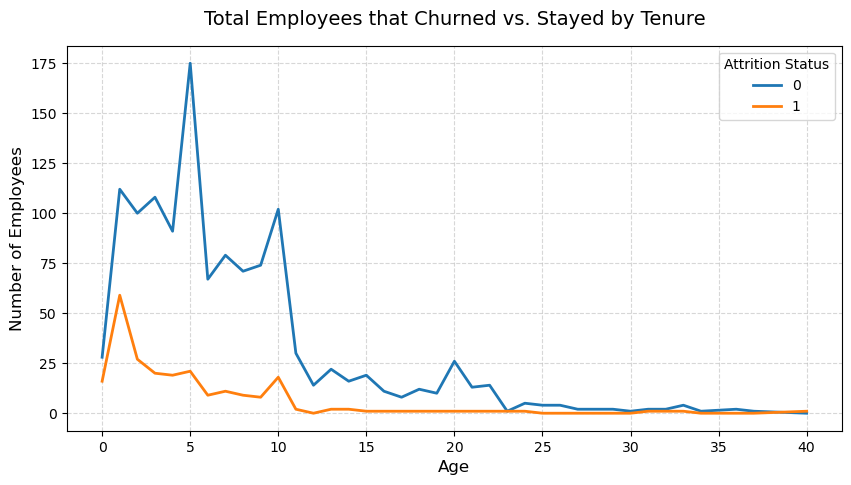

In [56]:
plot_data = employee_data.groupby(['YearsAtCompany', 'Attrition']).size().unstack(fill_value=0)

# Plotting directly using pandas wrapper (avoiding .figure() as per guidelines)
ax = plot_data.plot(kind='line', linewidth=2, figsize=(10, 5))

# Formatting labels and titles to ensure they are clear and non-overlapping
ax.set_title('Total Employees that Churned vs. Stayed by Tenure', fontsize=14, pad=15)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Number of Employees', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Attrition Status');


__YearsAtCompany is right skewed with median =5 years and the 75% of employees have 9 years or less(From Numeric Data Summary section)__
__The tenure split of bands is uneven to ensure that we capture accurately the behavior in the early years.__


In [57]:
#Create a tenure foreign key in the fact table.
tenure_bins   = [-1, 2, 5, 10, 20, 100]
tenure_labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs']
 
employee_data['TenureGroup'] = pd.cut(employee_data['YearsAtCompany'], bins=tenure_bins, labels=tenure_labels)


### Assess Employee Allocations In Tenure

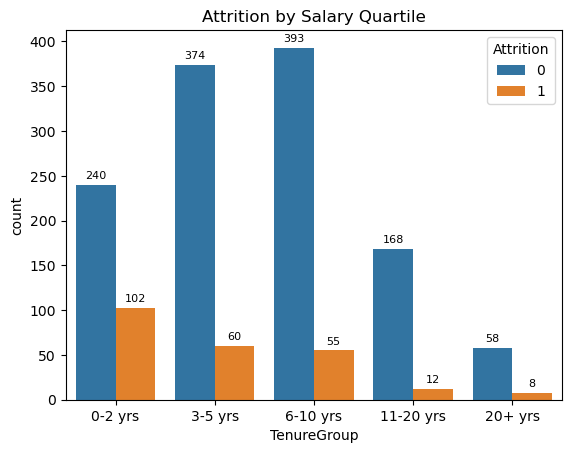

In [58]:
ax=sns.countplot(data=employee_data ,x='TenureGroup', hue='Attrition')

# Add labels to each bar
for container in ax.containers:
    ax.bar_label(container,fontsize=8,padding=3)
plt.title('Attrition by Salary Quartile')
plt.show();

__TenureGroup Comments__
* The 11-20yrs & 20+yrs groups have very little exposure to employees leaving.__I will be grouping them together into 11+yrs

In [59]:
#Create a tenure foreign key in the fact table.
tenure_bins   = [-1, 2, 5, 10, 100]
tenure_labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11+ yrs']
 
employee_data['TenureGroup'] = pd.cut(employee_data['YearsAtCompany'], bins=tenure_bins, labels=tenure_labels)

In [60]:
employee_data['TenureGroup'].unique()

['6-10 yrs', '0-2 yrs', '3-5 yrs', '11+ yrs']
Categories (4, str): ['0-2 yrs' < '3-5 yrs' < '6-10 yrs' < '11+ yrs']

### Assess MonthlyIncome to create Salary Bands

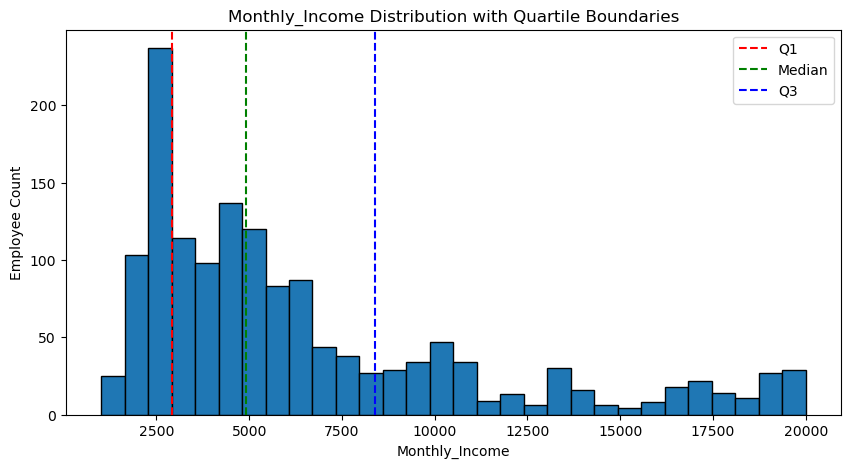

In [61]:
q1 = employee_data['MonthlyIncome'].quantile(0.25)
q2 = employee_data['MonthlyIncome'].quantile(0.50)
q3 = employee_data['MonthlyIncome'].quantile(0.75)

plt.figure(figsize=(10,5))
plt.hist(employee_data['MonthlyIncome'], bins=30, edgecolor='black')

plt.axvline(q1, color='red', linestyle='--', label='Q1')
plt.axvline(q2, color='green', linestyle='--', label='Median')
plt.axvline(q3, color='blue', linestyle='--', label='Q3')

plt.title('Monthly_Income Distribution with Quartile Boundaries')
plt.xlabel('Monthly_Income')
plt.ylabel('Employee Count')
plt.legend()
plt.show()

__I used quartiles because MonthlyIncome ir right skewed to ensure that each quartile band contains roughly the same number of employees__

In [62]:
salary_labels = ['Q1 - Lower', 'Q2 - Lower-Middle', 'Q3 - Upper-Middle', 'Q4 - Upper']
employee_data['SalaryBand'], bin_edges = pd.qcut(employee_data['MonthlyIncome'], q=4, labels=salary_labels, retbins=True)

### Convert Binary Features & satisfaction features to labels for Modeling

In [63]:
Attrition_map = {0: 'No', 1: 'Yes'}
Overtime_map = {0: 'No', 1: 'Yes'}
employee_data['Attrition'] = employee_data['Attrition'].map(Attrition_map)
employee_data['OverTime'] = employee_data['OverTime'].map(Overtime_map)

In [64]:
employee_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Attrition                1470 non-null   str     
 1   BusinessTravel           1470 non-null   str     
 2   DailyRate                1470 non-null   int64   
 3   DistanceFromHome         1470 non-null   int64   
 4   EducationField           1470 non-null   str     
 5   EmployeeNumber           1470 non-null   int64   
 6   EnvironmentSatisfaction  1470 non-null   int64   
 7   JobInvolvement           1470 non-null   int64   
 8   JobRole                  1470 non-null   str     
 9   JobSatisfaction          1470 non-null   int64   
 10  MaritalStatus            1470 non-null   str     
 11  MonthlyIncome            1470 non-null   int64   
 12  OverTime                 1470 non-null   str     
 13  StockOptionLevel         1470 non-null   int64   
 14  TrainingTimesLastYe

In [65]:
satisfaction_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}

employee_data['JobSatisfaction'] = employee_data['JobSatisfaction'].map(satisfaction_map)
employee_data['EnvironmentSatisfaction'] = employee_data['EnvironmentSatisfaction'].map(satisfaction_map)

In [66]:
employee_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Attrition                1470 non-null   str     
 1   BusinessTravel           1470 non-null   str     
 2   DailyRate                1470 non-null   int64   
 3   DistanceFromHome         1470 non-null   int64   
 4   EducationField           1470 non-null   str     
 5   EmployeeNumber           1470 non-null   int64   
 6   EnvironmentSatisfaction  1470 non-null   str     
 7   JobInvolvement           1470 non-null   int64   
 8   JobRole                  1470 non-null   str     
 9   JobSatisfaction          1470 non-null   str     
 10  MaritalStatus            1470 non-null   str     
 11  MonthlyIncome            1470 non-null   int64   
 12  OverTime                 1470 non-null   str     
 13  StockOptionLevel         1470 non-null   int64   
 14  TrainingTimesLastYe

In [67]:
employee_data.columns

Index(['Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome',
       'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'OverTime', 'StockOptionLevel',
       'TrainingTimesLastYear', 'YearsAtCompany', 'TenureGroup', 'SalaryBand'],
      dtype='str')

### Assess Segments

In [68]:
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 10)

In [69]:
EFFECT_SIZE_THRESHOLD = 0.20 # Cramer's V minimum to be considered "meaningful"
RELIABILITY_THRESHOLD = 20 # minimum segment size to trust a cell combination.

In [70]:

candidate_vars = ['OverTime', 'TenureGroup', 'SalaryBand', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'JobRole', 'MaritalStatus', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'EducationField','JobInvolvement'
    ,'StockOptionLevel','TrainingTimesLastYear']


### Feature*Feature Segment Testing

In [71]:
df=employee_data

In [72]:
def test_combination(df, var1, var2):
    """Combine two variables into one segment, test vs Attrition, and find the riskiest sub-segment."""
    combo_col = df[var1].astype(str) + ' | ' + df[var2].astype(str)
    contingency = pd.crosstab(combo_col, df['Attrition'])

    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    r, k = contingency.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    min_expected = expected.min()

    # Find the single highest-attrition sub-segment within this combination
    segment_sizes = contingency.sum(axis=1)
    attrition_rates = contingency['Yes'] / segment_sizes
    reliable_mask = segment_sizes >= RELIABILITY_THRESHOLD
    if reliable_mask.sum() == 0:
        return None # no reliable sub-segment at all, skip this combination entirely

    reliable_rates = attrition_rates[reliable_mask]
    top_segment_label = reliable_rates.idxmax()
    top_segment_rate = reliable_rates.max()
    top_segment_size = segment_sizes[top_segment_label]

    return {
        'Variable1': var1,
        'Variable2': var2,
        'CramersV': round(cramers_v, 3),
        'ChiSquare_p': p,
        'MinExpectedCount': round(min_expected, 2),
        'AssumptionMet(>=5)': min_expected >= 5,
        'TopSegment': top_segment_label,
        'TopSegmentAttritionRate': round(top_segment_rate * 100, 1),
        'TopSegmentSize': int(top_segment_size)
    }


In [73]:
# --- Test every pairwise combination ---
results = []
for var1, var2 in combinations(candidate_vars, 2):
    result = test_combination(df, var1, var2)
    if result is not None:
        results.append(result)

results_df = pd.DataFrame(results)

# --- Filter to meaningful effect size, then sort by highest attrition rate found ---
filtered = results_df[results_df['CramersV'] > EFFECT_SIZE_THRESHOLD].copy()
filtered = filtered.sort_values('TopSegmentAttritionRate', ascending=False)

print(f"Tested {len(results_df)} valid combinations out of {len(list(combinations(candidate_vars, 2)))} possible pairs")
print(f"{len(filtered)} combinations passed Cramer's V > {EFFECT_SIZE_THRESHOLD}")
print()
print(filtered.to_string(index=False))

filtered.to_csv('segment_test_results.csv', index=False)
# print("\nSaved segment_test_results.csv")


Tested 78 valid combinations out of 91 possible pairs
67 combinations passed Cramer's V > 0.2

              Variable1               Variable2  CramersV  ChiSquare_p  MinExpectedCount  AssumptionMet(>=5)                               TopSegment  TopSegmentAttritionRate  TopSegmentSize
               OverTime                 JobRole     0.377 3.533889e-35              2.10               False               Yes | Sales Representative                     66.7              24
                JobRole          BusinessTravel     0.295 2.240309e-15              0.64               False Sales Representative | Travel_Frequently                     65.2              23
            TenureGroup          JobInvolvement     0.264 3.824365e-15              2.10               False                              0-2 yrs | 1                     59.1              22
               OverTime              SalaryBand     0.358 3.988430e-37             15.48                True                         Yes | Q1

In [74]:
segments= filtered.copy()

In [75]:
segments[segments['AssumptionMet(>=5)'] == True]

,Variable1,Variable2,CramersV,ChiSquare_p,MinExpectedCount,AssumptionMet(>=5),TopSegment,TopSegmentAttritionRate,TopSegmentSize
1,OverTime,SalaryBand,0.358,3.988430e-37,15.48,True,Yes | Q1 - Lower,58.5,106
3,OverTime,EnvironmentSatisfaction,0.298,5.476885e-25,10.00,True,Yes | Low,51.6,62
0,OverTime,TenureGroup,0.336,1.932445e-32,10.48,True,Yes | 0-2 yrs,51.0,104
5,OverTime,MaritalStatus,0.324,1.636088e-31,15.96,True,Yes | Single,49.6,131
27,SalaryBand,BusinessTravel,0.260,2.102140e-16,5.48,True,Q1 - Lower | Travel_Frequently,47.3,74
16,TenureGroup,MaritalStatus,0.282,9.098468e-20,9.19,True,0-2 yrs | Single,43.5,131
14,TenureGroup,EnvironmentSatisfaction,0.247,1.118246e-12,7.09,True,0-2 yrs | Low,43.1,72
23,SalaryBand,JobSatisfaction,0.250,4.014470e-13,9.83,True,Q1 - Lower | Low,42.9,63
24,SalaryBand,EnvironmentSatisfaction,0.255,8.320362e-14,10.16,True,Q1 - Lower | Low,42.0,69
6,OverTime,BusinessTravel,0.275,2.369089e-22,5.64,True,Yes | Travel_Frequently,41.9,86


__Comments 2 features Combination__
* Overtime & Salary band(Q1 - Lower) has the highest attrition= 58.5% being the highest segment
* Overtime & EnvironmentSatisfaction(Low) has the highest attrition= 51.6% being the 2nd highest segment
* Overtime & TenureGroup(0-2 yrs) has the highest attrition= 51.0% being the 3rd  highest segment

### Feature * Feature * Feature Segment Testing

In [76]:
def test_combination(df, var_list):
    """Combine N variables into one segment, test vs Attrition, find riskiest reliable sub-segment."""
    combo_col = df[var_list[0]].astype(str)
    for v in var_list[1:]:
        combo_col = combo_col + ' | ' + df[v].astype(str)

    contingency = pd.crosstab(combo_col, df['Attrition'])

    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    r, k = contingency.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    min_expected = expected.min()

    segment_sizes = contingency.sum(axis=1)
    attrition_rates = contingency['Yes'] / segment_sizes
    reliable_mask = segment_sizes >= RELIABILITY_THRESHOLD
    if reliable_mask.sum() == 0:
        return None

    reliable_rates = attrition_rates[reliable_mask]
    top_segment_label = reliable_rates.idxmax()
    top_segment_rate = reliable_rates.max()
    top_segment_size = segment_sizes[top_segment_label]

    return {
        'Variables': ' + '.join(var_list),
        'TotalCells': len(contingency),
        'ReliableCells': int(reliable_mask.sum()),
        'CramersV': round(cramers_v, 3),
        'ChiSquare_p': p,
        'MinExpectedCount': round(min_expected, 2),
        'AssumptionMet(>=5)': min_expected >= 5,
        'TopSegment': top_segment_label,
        'TopSegmentAttritionRate': round(top_segment_rate * 100, 1),
        'TopSegmentSize': int(top_segment_size)
    }

results = []
all_triplets = list(combinations(candidate_vars, 3))
for var_list in all_triplets:
    result = test_combination(df, list(var_list))
    if result is not None:
        results.append(result)

results_df = pd.DataFrame(results)

filtered = results_df[
    (results_df['CramersV'] > EFFECT_SIZE_THRESHOLD) &
    (results_df['AssumptionMet(>=5)'] == True)
].copy()
filtered = filtered.sort_values('TopSegmentAttritionRate', ascending=False)

print(f"Tested {len(results_df)} valid triplets out of {len(all_triplets)} possible combinations")
print(f"{len(filtered)} passed BOTH Cramer's V > {EFFECT_SIZE_THRESHOLD} AND the Chi-Square assumption")
print()
print(filtered.to_string(index=False))

Tested 283 valid triplets out of 364 possible combinations
0 passed BOTH Cramer's V > 0.2 AND the Chi-Square assumption

Empty DataFrame
Columns: [Variables, TotalCells, ReliableCells, CramersV, ChiSquare_p, MinExpectedCount, AssumptionMet(>=5), TopSegment, TopSegmentAttritionRate, TopSegmentSize]
Index: []


__3 Feature Testing Comments__
* None of the combinations are viable because cell sizes are too small and all combinations in turn fail the Chi-sq test minimum size requirement.

### Convert EmployeeNumber Into EmployeeID
* Conversion reasonable because we have each row representing a unique employee

In [77]:
employee_data.rename(columns = {'EmployeeNumber':'EmployeeID'},inplace=True)

### Assess YearsAtCompany to create the tenure dimension table

In [78]:
employee_data.head()

,Attrition,BusinessTravel,DailyRate,DistanceFromHome,EducationField,...,StockOptionLevel,TrainingTimesLastYear,YearsAtCompany,TenureGroup,SalaryBand
0,Yes,Travel_Rarely,1102,1,Life Sciences,...,0,0,6,6-10 yrs,Q3 - Upper-Middle
1,No,Travel_Frequently,279,8,Life Sciences,...,1,3,10,6-10 yrs,Q3 - Upper-Middle
2,Yes,Travel_Rarely,1373,2,Other,...,0,3,0,0-2 yrs,Q1 - Lower
3,No,Travel_Frequently,1392,3,Life Sciences,...,0,3,8,6-10 yrs,Q1 - Lower
4,No,Travel_Rarely,591,2,Medical,...,1,3,2,0-2 yrs,Q2 - Lower-Middle


## Remember to assess code adjustment

In [79]:
dim_tenure_group = pd.DataFrame({
    'TenureGroupID': range(1, len(tenure_labels) + 1),
    'TenureGroup': tenure_labels,
    'SortOrder': range(1, len(tenure_labels) + 1)
})

tenure_map = dict(zip(dim_tenure_group['TenureGroup'], dim_tenure_group['TenureGroupID']))

employee_data['TenureGroupID'] = employee_data['TenureGroup'].map(tenure_map)

employee_data = employee_data.drop(columns=['TenureGroup'])

print(employee_data[['EmployeeID', 'YearsAtCompany', 'TenureGroupID']].head())

   EmployeeID  YearsAtCompany TenureGroupID
0           1               6             3
1           2              10             3
2           4               0             1
3           5               8             3
4           7               2             1


### Create Tenure csv dim table

In [80]:
dim_tenure_group.to_csv("dim_tenure_group.csv",index=False)

In [81]:
dim_tenure_group

,TenureGroupID,TenureGroup,SortOrder
0,1,0-2 yrs,1
1,2,3-5 yrs,2
2,3,6-10 yrs,3
3,4,11+ yrs,4


### Create a salary dimension table

In [82]:
dim_salary_band = pd.DataFrame({
    'SalaryBandID': range(1, len(salary_labels) + 1),
    'SalaryBand': salary_labels,
    'SortOrder': range(1, len(salary_labels) + 1),
    'RangeLow': [round(bin_edges[i]) for i in range(4)],
    'RangeHigh': [round(bin_edges[i+1]) for i in range(4)]
})

salary_map = dict(zip(dim_salary_band['SalaryBand'], dim_salary_band['SalaryBandID']))
employee_data['SalaryBandID'] = employee_data['SalaryBand'].map(salary_map)
employee_data = employee_data.drop(columns=['SalaryBand'])

print(employee_data[['EmployeeID', 'MonthlyIncome', 'SalaryBandID']].head())

   EmployeeID  MonthlyIncome SalaryBandID
0           1           5993            3
1           2           5130            3
2           4           2090            1
3           5           2909            1
4           7           3468            2


In [83]:
dim_salary_band.to_csv("dim_salary_group.csv",index=False)

In [84]:
dim_salary_band

,SalaryBandID,SalaryBand,SortOrder,RangeLow,RangeHigh
0,1,Q1 - Lower,1,1009,2911
1,2,Q2 - Lower-Middle,2,2911,4919
2,3,Q3 - Upper-Middle,3,4919,8379
3,4,Q4 - Upper,4,8379,19999


### Create a fact table from the employee dataset

In [85]:
employee_data.head()

,Attrition,BusinessTravel,DailyRate,DistanceFromHome,EducationField,...,StockOptionLevel,TrainingTimesLastYear,YearsAtCompany,TenureGroupID,SalaryBandID
0,Yes,Travel_Rarely,1102,1,Life Sciences,...,0,0,6,3,3
1,No,Travel_Frequently,279,8,Life Sciences,...,1,3,10,3,3
2,Yes,Travel_Rarely,1373,2,Other,...,0,3,0,1,1
3,No,Travel_Frequently,1392,3,Life Sciences,...,0,3,8,3,1
4,No,Travel_Rarely,591,2,Medical,...,1,3,2,1,2


In [86]:
employee_data.to_csv("employee_data_fact.csv",index=False)